✓ 导入库完成
✓ 动力学模型定义完成
✓ 成功加载数据文件
  数据形状: (5000, 100, 6)
  数据格式: (轨迹数, 时间步, 状态+控制维度)
  ✓ 数据格式正确: 5000 轨迹, 100 时间步, 6维 (4状态+2控制)
✓ 数据转换完成
  转换了 20 条轨迹
  每条轨迹: 状态 (100, 4), 控制 (100, 2)

📊 数据集统计:
  状态范围:
    θ1: [0.181, 5.899] rad
    θ2: [0.072, 6.187] rad
    ω1: [-4.333, 7.441] rad/s
    ω2: [-6.822, 5.095] rad/s
  控制范围:
    τ1: [-25.704, 22.515] N⋅m
    τ2: [-23.159, 24.888] N⋅m
🔍 验证数据完整性...
  轨迹 0: 末端执行器X范围 [-1.083, 0.613], 违反障碍x=-0.25: 8/100 次
  轨迹 1: 末端执行器X范围 [-0.917, 1.935], 违反障碍x=-0.25: 9/100 次
  轨迹 2: 末端执行器X范围 [-0.326, 0.999], 违反障碍x=-0.25: 5/100 次
  轨迹 3: 末端执行器X范围 [-0.027, 0.036], 违反障碍x=-0.25: 0/100 次
  轨迹 4: 末端执行器X范围 [-0.610, 0.215], 违反障碍x=-0.25: 5/100 次

📈 安全性统计 (障碍位置 x=-0.25):
  总违反次数: 27/500 (5.4%)
  需要优化的轨迹: 4/5
🧪 快速功能测试...
  ✓ 动力学方程测试: f([0.78539816 1.04719755], [ 1.  -0.5]) = [ 0.1 -0.1]
  ✓ RK4积分测试: 下一状态前两维 = [0.82971861 1.04371852]
  ✓ 前向运动学测试: 末端执行器位置 = (1.573, -1.207)
  ✓ 所有功能测试通过

🎉 准备工作完成！
✅ 数据加载成功: 20 条轨迹已准备就绪
✅ 动力学模型已定义并测试通过
✅ 变量 'generated_trajectories' 已创建，三步优化器可以直

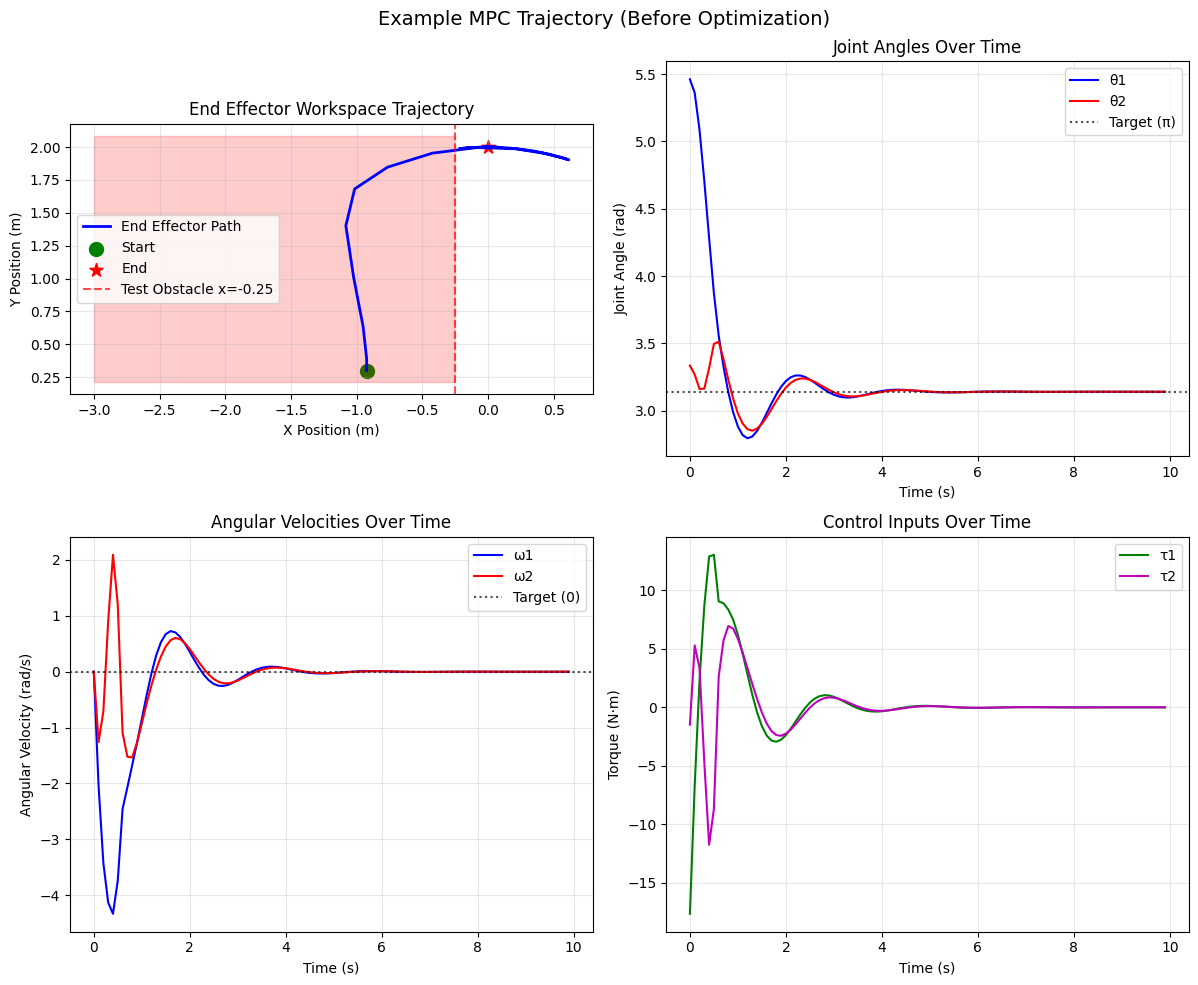

示例轨迹统计:
  初始角度: θ1=5.461, θ2=3.335
  最终角度: θ1=3.142, θ2=3.142
  目标角度: θ1=π=3.142, θ2=π=3.142
  末端执行器X范围: [-1.083, 0.613]
  障碍违反 (x<-0.25): 8/100 次
  平均控制幅度: τ1=1.391, τ2=0.980


In [1]:
# %%
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

print("✓ 导入库完成")

# %%
# 定义双摆动力学类（与三步优化器兼容）
class DoublePendulumDynamics:
    """双摆动力学模型"""
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        """动力学方程 dx/dt = f(x, u)"""
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        
        # 质量矩阵
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        
        # 科里奥利和离心力
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        
        # 重力项
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        
        # 求解关节加速度
        M = np.array([[M11, M12], [M21, M22]])
        CG = np.array([C1 + G1, C2 + G2])
        
        try:
            dd = np.linalg.solve(M, u - CG)
        except np.linalg.LinAlgError:
            # 如果矩阵奇异，使用伪逆
            dd = np.linalg.pinv(M) @ (u - CG)
        
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        """四阶龙格-库塔积分"""
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

print("✓ 动力学模型定义完成")

# %%
# 加载MPC轨迹数据集
try:
    # 尝试加载数据文件
    mpc_data = np.load('mpc_trajectories.npy')
    print(f"✓ 成功加载数据文件")
    print(f"  数据形状: {mpc_data.shape}")
    print(f"  数据格式: (轨迹数, 时间步, 状态+控制维度)")
    
    # 检查数据格式
    if len(mpc_data.shape) == 3 and mpc_data.shape[2] == 6:
        print(f"  ✓ 数据格式正确: {mpc_data.shape[0]} 轨迹, {mpc_data.shape[1]} 时间步, 6维 (4状态+2控制)")
    else:
        print(f"  ⚠ 数据格式可能不正确，期望 (N, T, 6)，实际 {mpc_data.shape}")
        
except FileNotFoundError:
    print("❌ 找不到 'mpc_trajectories.npy' 文件")
    print("请确保文件在当前目录下，或者修改文件路径")
    mpc_data = None
except Exception as e:
    print(f"❌ 加载数据时出错: {e}")
    mpc_data = None

# %%
# 将MPC数据转换为三步优化器期望的格式
if mpc_data is not None:
    # 选择前20条轨迹进行测试
    N_TEST_TRAJECTORIES = min(20, mpc_data.shape[0])
    
    # 创建generated_trajectories列表（三步优化器期望的格式）
    generated_trajectories = []
    
    for i in range(N_TEST_TRAJECTORIES):
        trajectory_data = mpc_data[i]  # 形状: (100, 6)
        
        # 分离状态和控制
        states = trajectory_data[:, :4]    # (100, 4) - θ1, θ2, ω1, ω2
        controls = trajectory_data[:, 4:]  # (100, 2) - τ1, τ2
        
        # 创建轨迹字典
        trajectory_dict = {
            'states': states,
            'controls': controls
        }
        
        generated_trajectories.append(trajectory_dict)
    
    print(f"✓ 数据转换完成")
    print(f"  转换了 {N_TEST_TRAJECTORIES} 条轨迹")
    print(f"  每条轨迹: 状态 {generated_trajectories[0]['states'].shape}, 控制 {generated_trajectories[0]['controls'].shape}")
    
    # 数据统计
    print(f"\n📊 数据集统计:")
    all_states = np.concatenate([traj['states'] for traj in generated_trajectories], axis=0)
    all_controls = np.concatenate([traj['controls'] for traj in generated_trajectories], axis=0)
    
    print(f"  状态范围:")
    print(f"    θ1: [{all_states[:,0].min():.3f}, {all_states[:,0].max():.3f}] rad")
    print(f"    θ2: [{all_states[:,1].min():.3f}, {all_states[:,1].max():.3f}] rad") 
    print(f"    ω1: [{all_states[:,2].min():.3f}, {all_states[:,2].max():.3f}] rad/s")
    print(f"    ω2: [{all_states[:,3].min():.3f}, {all_states[:,3].max():.3f}] rad/s")
    
    print(f"  控制范围:")
    print(f"    τ1: [{all_controls[:,0].min():.3f}, {all_controls[:,0].max():.3f}] N⋅m")
    print(f"    τ2: [{all_controls[:,1].min():.3f}, {all_controls[:,1].max():.3f}] N⋅m")
    
else:
    print("❌ 无法转换数据，请先正确加载数据文件")
    generated_trajectories = None

# %%
# 验证数据和检查安全性（可选）
if generated_trajectories is not None:
    print("🔍 验证数据完整性...")
    
    # 创建一个临时的优化器来计算末端执行器位置
    dyn_temp = DoublePendulumDynamics()
    
    def forward_kinematics_temp(state, l1=1.0, l2=1.0):
        """临时前向运动学函数"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return x2, y2
    
    # 检查几条轨迹的安全性
    obstacle_x = -0.25  # 测试障碍位置
    safety_stats = []
    
    for i in range(min(5, len(generated_trajectories))):
        traj = generated_trajectories[i]
        states = traj['states']
        
        # 计算末端执行器位置
        ee_positions = []
        for state in states:
            x_ee, y_ee = forward_kinematics_temp(state)
            ee_positions.append([x_ee, y_ee])
        ee_positions = np.array(ee_positions)
        
        # 检查安全违反
        violations = np.sum(ee_positions[:, 0] < obstacle_x)
        safety_stats.append(violations)
        
        print(f"  轨迹 {i}: 末端执行器X范围 [{ee_positions[:,0].min():.3f}, {ee_positions[:,0].max():.3f}], "
              f"违反障碍x={obstacle_x}: {violations}/{len(states)} 次")
    
    total_violations = sum(safety_stats)
    total_timesteps = len(safety_stats) * len(generated_trajectories[0]['states'])
    
    print(f"\n📈 安全性统计 (障碍位置 x={obstacle_x}):")
    print(f"  总违反次数: {total_violations}/{total_timesteps} ({total_violations/total_timesteps*100:.1f}%)")
    print(f"  需要优化的轨迹: {sum(1 for v in safety_stats if v > 0)}/{len(safety_stats)}")

# %%
# 快速功能测试
if generated_trajectories is not None:
    print("🧪 快速功能测试...")
    
    try:
        # 测试动力学方程
        test_state = np.array([np.pi/4, np.pi/3, 0.1, -0.1])
        test_control = np.array([1.0, -0.5])
        
        dyn_test = DoublePendulumDynamics()
        
        # 测试动力学计算
        dx = dyn_test.f(test_state, test_control)
        print(f"  ✓ 动力学方程测试: f({test_state[:2]}, {test_control}) = {dx[:2]}")
        
        # 测试积分
        next_state = dyn_test.rk4_step(test_state, test_control, 0.1)
        print(f"  ✓ RK4积分测试: 下一状态前两维 = {next_state[:2]}")
        
        # 测试前向运动学
        x_ee, y_ee = forward_kinematics_temp(test_state)
        print(f"  ✓ 前向运动学测试: 末端执行器位置 = ({x_ee:.3f}, {y_ee:.3f})")
        
        print("  ✓ 所有功能测试通过")
        
    except Exception as e:
        print(f"  ❌ 功能测试失败: {e}")

# %%
# 准备工作完成提示
print("\n" + "="*60)
print("🎉 准备工作完成！")
print("="*60)

if generated_trajectories is not None:
    print(f"✅ 数据加载成功: {len(generated_trajectories)} 条轨迹已准备就绪")
    print(f"✅ 动力学模型已定义并测试通过")
    print(f"✅ 变量 'generated_trajectories' 已创建，三步优化器可以直接使用")
    print(f"\n🚀 现在可以运行三步式CBF-CLF优化器了！")
    print(f"\n📝 使用建议:")
    print(f"   - 轨迹索引范围: 0-{len(generated_trajectories)-1}")
    print(f"   - 建议障碍位置: -0.3 到 -0.1")
    print(f"   - 推荐测试轨迹: 0, 3, 7, 12, 18 (随机选择)")
else:
    print("❌ 数据准备失败，请检查数据文件")
    print("📋 故障排除:")
    print("   1. 确认 'mpc_trajectories.npy' 文件在当前目录")
    print("   2. 检查文件是否损坏")
    print("   3. 确认数据格式为 (N, T, 6)")

print("="*60)

# %%
# 可选：可视化一条示例轨迹
if generated_trajectories is not None:
    # 选择第一条轨迹进行可视化
    example_traj = generated_trajectories[0]
    example_states = example_traj['states']
    example_controls = example_traj['controls']
    
    # 计算末端执行器轨迹
    ee_trajectory = []
    for state in example_states:
        x_ee, y_ee = forward_kinematics_temp(state)
        ee_trajectory.append([x_ee, y_ee])
    ee_trajectory = np.array(ee_trajectory)
    
    # 创建可视化
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Example MPC Trajectory (Before Optimization)', fontsize=14)
    
    time_steps = np.arange(len(example_states)) * 0.1
    
    # 1. 末端执行器轨迹
    ax1.plot(ee_trajectory[:, 0], ee_trajectory[:, 1], 'b-', linewidth=2, label='End Effector Path')
    ax1.scatter(ee_trajectory[0, 0], ee_trajectory[0, 1], c='green', s=100, marker='o', label='Start')
    ax1.scatter(ee_trajectory[-1, 0], ee_trajectory[-1, 1], c='red', s=100, marker='*', label='End')
    
    # 添加测试障碍
    test_obstacle = -0.25
    ax1.axvline(x=test_obstacle, color='red', linestyle='--', alpha=0.7, label=f'Test Obstacle x={test_obstacle}')
    ax1.fill_betweenx(ax1.get_ylim(), -3, test_obstacle, alpha=0.2, color='red')
    
    ax1.set_xlabel('X Position (m)')
    ax1.set_ylabel('Y Position (m)')
    ax1.set_title('End Effector Workspace Trajectory')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # 2. 关节角度
    ax2.plot(time_steps, example_states[:, 0], 'b-', label='θ1')
    ax2.plot(time_steps, example_states[:, 1], 'r-', label='θ2')
    ax2.axhline(y=np.pi, color='k', linestyle=':', alpha=0.7, label='Target (π)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Joint Angle (rad)')
    ax2.set_title('Joint Angles Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 角速度
    ax3.plot(time_steps, example_states[:, 2], 'b-', label='ω1')
    ax3.plot(time_steps, example_states[:, 3], 'r-', label='ω2')
    ax3.axhline(y=0, color='k', linestyle=':', alpha=0.7, label='Target (0)')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Angular Velocity (rad/s)')
    ax3.set_title('Angular Velocities Over Time')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. 控制输入
    ax4.plot(time_steps, example_controls[:, 0], 'g-', label='τ1')
    ax4.plot(time_steps, example_controls[:, 1], 'm-', label='τ2')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Torque (N⋅m)')
    ax4.set_title('Control Inputs Over Time')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 统计信息
    violations = np.sum(ee_trajectory[:, 0] < test_obstacle)
    print(f"示例轨迹统计:")
    print(f"  初始角度: θ1={example_states[0,0]:.3f}, θ2={example_states[0,1]:.3f}")
    print(f"  最终角度: θ1={example_states[-1,0]:.3f}, θ2={example_states[-1,1]:.3f}")
    print(f"  目标角度: θ1=π={np.pi:.3f}, θ2=π={np.pi:.3f}")
    print(f"  末端执行器X范围: [{ee_trajectory[:,0].min():.3f}, {ee_trajectory[:,0].max():.3f}]")
    print(f"  障碍违反 (x<{test_obstacle}): {violations}/{len(example_states)} 次")
    print(f"  平均控制幅度: τ1={np.abs(example_controls[:,0]).mean():.3f}, τ2={np.abs(example_controls[:,1]).mean():.3f}")

=== 三步式CBF-CLF优化测试 ===
将对轨迹 5 进行优化
障碍位置设置为 x = -0.2
=== 使用FM生成轨迹进行三步优化测试 ===
轨迹索引: 5
障碍位置: x_min = -0.2
✓ 成功加载FM轨迹 5
  状态轨迹形状: (100, 4)
  控制轨迹形状: (100, 2)

原始轨迹分析:
  CBF违反次数: 12/100
  末端执行器X范围: [-1.970, 0.868]
  ⚠ 原始轨迹违反安全约束，需要优化

开始三步优化...
开始三步式CBF-CLF轨迹优化
障碍位置: x_min = -0.2
轨迹长度: 100 步
=== Stage 1: CBF-Hard (State Optimization) ===
  ⚠ Stage1 未收敛，保留原始状态轨迹
  CBF 硬约束违反次数: 12/100
  优化成功: False, nit: 300, 用时: 500.91s

=== Stage 2: Pure CLF (Control Correction) ===
  优化变量维度: 198
  目标: 最小化动力学残差
  优化时间: 0.75s
  优化成功: True
  动力学误差: 0.000000
  目标函数值: 0.000000

=== Stage 3: CBF-CLF Joint Refinement (trust-constr) ===
| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |  595  |   0   | +7.1072e+03 | 1.00e+00 | 1.64e+02 | 1.77e+00 |
|   2   | 1190  |   1   | +6.7578e+03 | 7.00e+00 | 4.35e+02 | 1.77e+00 |
|   3   | 1785  |  28   | +5.9288e+03 | 4.06e+01 | 4.24e+02 | 1.77e+00 |
|   4   | 2380  | 

KeyError: 'cbf_violations'

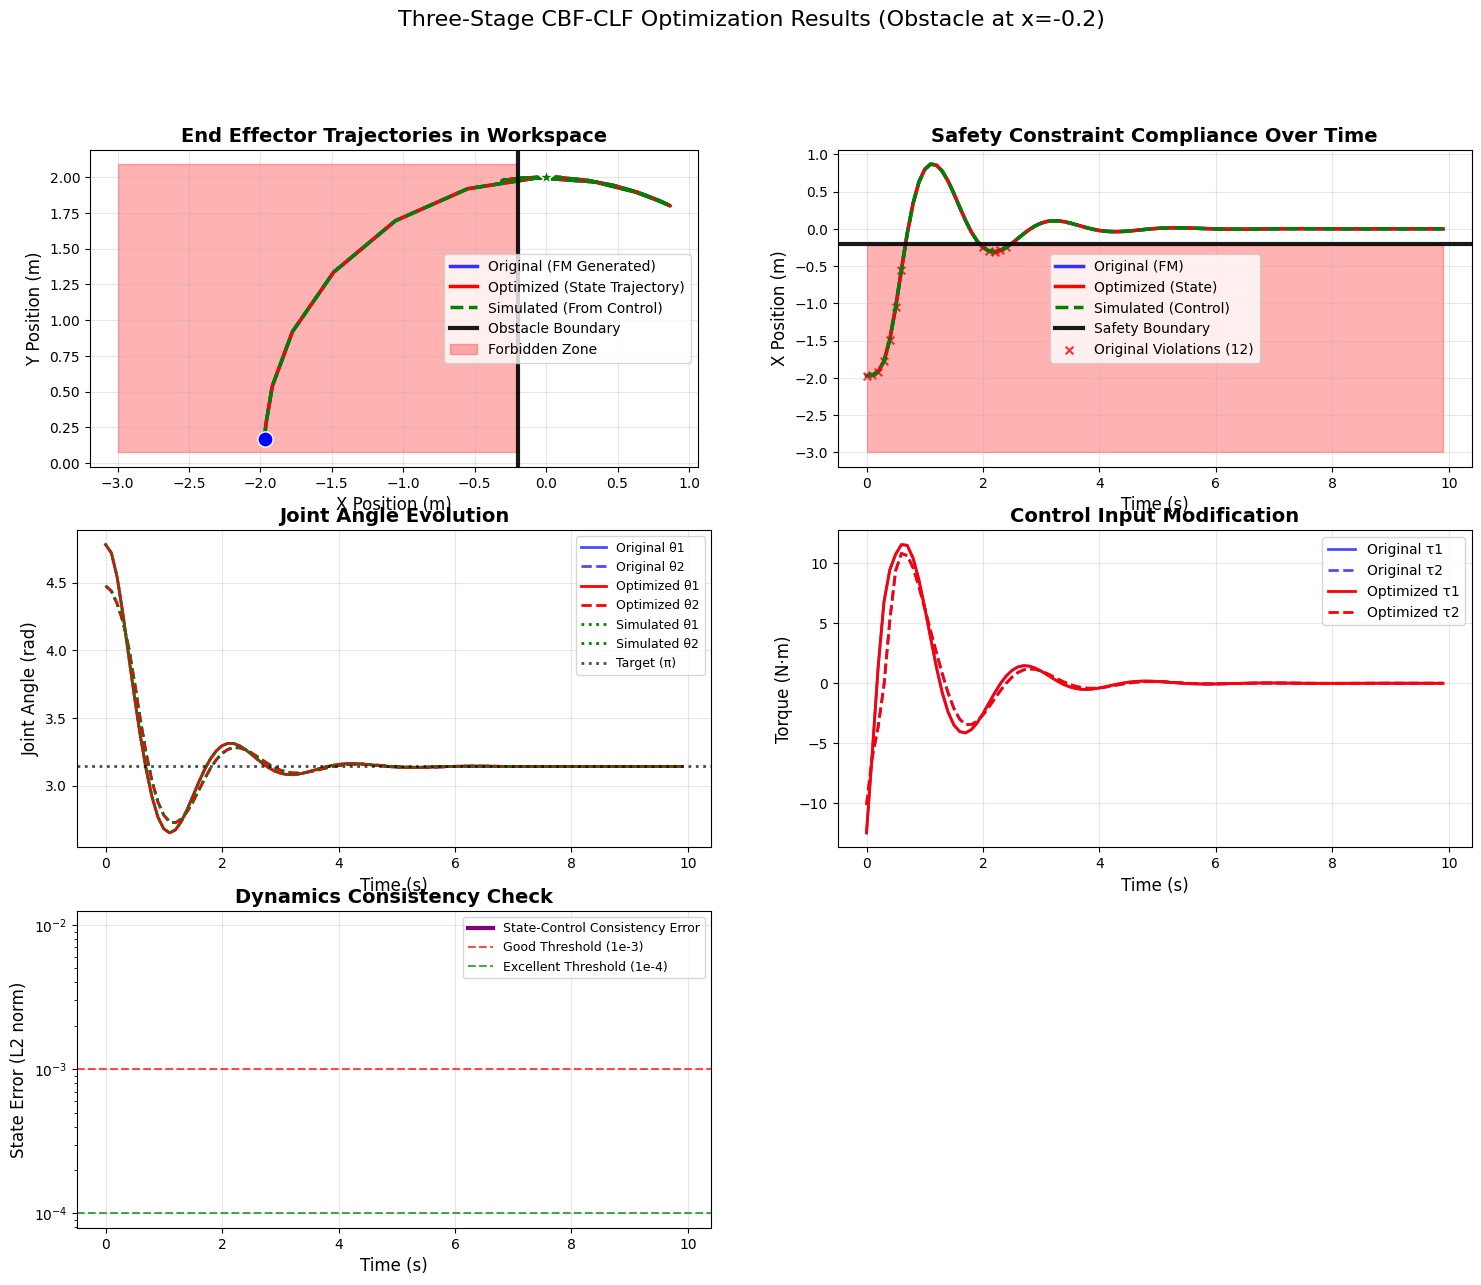

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

class ThreeStageOptimizer:
    """
    三步式CBF-CLF轨迹优化器
    
    Stage 1: CBF-softCLF - 纯状态修正，CBF硬约束，CLF软约束
    Stage 2: 纯CLF - 纯控制修正，最小化动力学残差
    Stage 3: CBF-CLF联合精细化 - 状态+控制微调，严格约束
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def cbf_constraint_value(self, state, x_min, margin=0.05):
        """CBF约束值：>0 安全，<0 违反"""
        end_pos = self.forward_kinematics(state)
        return end_pos[0] - (x_min + margin)
    
    def dynamics_residual(self, x_current, u, x_next_target):
        """动力学残差"""
        x_next_pred = self.dyn.rk4_step(x_current, u, self.dt)
        return x_next_pred - x_next_target
    
    def stage1_cbf_soft_clf(self, states_original, controls_original, x_min,
                        max_iter=300, verbose=True):
        """
        第一阶段：CBF-硬约束 + 最小动力学残差
        - 优化变量：所有 T 步的状态（包括初始状态）
        - 硬约束：∀ t,  x_ee(t) - x_min >= 0
        - 目标：最小化动力学残差
        """
        if verbose:
            print("=== Stage 1: CBF-Hard (State Optimization) ===")
        T = len(states_original)
        n_vars = T * 4  # 每个时刻 4 维状态

        def objective(x_flat):
            states_var = x_flat.reshape(T, 4)
            cost = 0.0
            for t in range(T - 1):
                x_cur = states_var[t]
                u_cur = controls_original[t]
                x_next_var = states_var[t + 1]
                x_next_dyn = self.dyn.rk4_step(x_cur, u_cur, self.dt)
                diff = x_next_var - x_next_dyn
                cost += np.sum(diff**2)
            # 状态正则化，避免漂移过远
            cost += 0.01 * np.sum((states_var - states_original)**2)
            return cost

        def cbf_ineq(x_flat):
            states_var = x_flat.reshape(T, 4)
            # 返回 ∀ t: x_ee(t) - x_min >= 0
            return np.array([
                self.forward_kinematics(states_var[t])[0] - x_min
                for t in range(T)
            ])

        # 构造约束和边界
        constraints = [{'type': 'ineq', 'fun': cbf_ineq}]
        bounds = [(-3*np.pi, 3*np.pi), (-3*np.pi, 3*np.pi),
                  (-25, 25),           (-25, 25)] * T
        x0 = states_original.flatten()

        start_time = time.time()
        result = minimize(
            objective, x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': max_iter, 'ftol': 1e-9, 'eps': 1e-9}
        )
        stage1_time = time.time() - start_time

        if result.success:
            states_opt = result.x.reshape(T, 4)
        else:
            if verbose:
                print("  ⚠ Stage1 未收敛，保留原始状态轨迹")
            states_opt = states_original.copy()

        # 最终检查是否有任何时刻 x_ee < x_min
        violations = sum(
            1 for t in range(T)
            if self.forward_kinematics(states_opt[t])[0] < x_min
        )

        if verbose:
            print(f"  CBF 硬约束违反次数: {violations}/{T}")
            print(f"  优化成功: {result.success}, nit: {result.nit}, 用时: {stage1_time:.2f}s")

        info = {
            'success':    result.success,
            'nit':        result.nit,
            'time':       stage1_time,
            'cbf_violations': violations,
            'objective':  result.fun,
        }
        return states_opt, info

    
    def stage2_pure_clf(self, states_corrected, controls_original, 
                       w_dynamics=1.0, max_iter=200, verbose=True):
        """
        第二步：纯CLF优化
        优化目标：仅修正控制轨迹
        约束：最小化动力学残差
        """
        if verbose:
            print("\n=== Stage 2: Pure CLF (Control Correction) ===")
        
        T = len(states_corrected)
        n_ctrl = T - 1
        # 优化变量：前T-1步控制 (T-1) x 2
        n_vars = n_ctrl * 2
        
        def objective(u_flat):
            """目标函数：最小化动力学残差"""
            controls_var = u_flat.reshape(n_ctrl, 2)
            
            dynamics_cost = 0.0
            for t in range(n_ctrl):
                x_current = states_corrected[t]
                u_current = controls_var[t]
                x_next_target = states_corrected[t+1]
                
                # 计算动力学残差
                residual = self.dynamics_residual(x_current, u_current, x_next_target)
                dynamics_cost += np.sum(residual**2)
            
            # 控制修正正则化（不要偏离原控制太远）
            control_deviation = controls_var - controls_original[:n_ctrl]
            regularization = 0.01 * np.sum(control_deviation**2)
            
            return w_dynamics * dynamics_cost + regularization
        
        # 控制边界
        bounds = [(-25, 25) for _ in range(n_vars)]
        
        # 初始猜测：原始控制
        u0 = controls_original[:n_ctrl].flatten()
        
        if verbose:
            print(f"  优化变量维度: {n_vars}")
            print(f"  目标: 最小化动力学残差")
        
        start_time = time.time()
        result = minimize(
            objective, u0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': max_iter, 'ftol': 1e-9}
        )
        stage2_time = time.time() - start_time
        
        if result.success:
            controls_var_opt = result.x.reshape(n_ctrl, 2)
            controls_stage2 = np.vstack([controls_var_opt, controls_original[-1:]])
        else:
            controls_stage2 = controls_original
        
        # 验证动力学一致性
        simulated_states = [states_corrected[0].copy()]
        for t in range(n_ctrl):
            x_next = self.dyn.rk4_step(simulated_states[-1], controls_stage2[t], self.dt)
            simulated_states.append(x_next)
        simulated_states = np.array(simulated_states)
        
        dynamics_error = np.mean(np.linalg.norm(simulated_states - states_corrected, axis=1))
        
        if verbose:
            print(f"  优化时间: {stage2_time:.2f}s")
            print(f"  优化成功: {result.success}")
            print(f"  动力学误差: {dynamics_error:.6f}")
            print(f"  目标函数值: {result.fun:.6f}")
        
        stage2_info = {
            'success': result.success,
            'time': stage2_time,
            'dynamics_error': dynamics_error,
            'objective_value': result.fun,
            'simulated_states': simulated_states
        }
        
        return controls_stage2, stage2_info
    
    def stage3_cbf_clf_refinement(self, states_stage1, controls_stage2, x_min,
                                  w_state=0.1, w_ctrl=0.1, w_dynamics=100.0, w_cbf=500.0,
                                  dynamics_threshold=1e-2, max_iter=50, verbose=True):
        """
        第三步：CBF-CLF 联合精细化（使用 trust-constr 提升质量）
        - 优化变量：T-1 步的状态微调 + T-1 步的控制微调
        - 硬约束1：动力学残差 ≤ dynamics_threshold
        - 硬约束2：末端执行器 x_ee ≥ x_min
        - 目标：状态+控制微调正则化 + 动力学误差 + CBF 软罚项
        """
        if verbose:
            print("\n=== Stage 3: CBF-CLF Joint Refinement (trust-constr) ===")

        T = len(states_stage1)
        n_ctrl = T - 1
        n_states_var   = (T-1) * 4
        n_controls_var = n_ctrl * 2
        n_vars = n_states_var + n_controls_var

        # Objective: 微调正则 + 动力学 + CBF 软罚
        def objective(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            ct_var = x[n_states_var:].reshape(n_ctrl, 2)
            states_full = np.vstack([states_stage1[0:1], st_var])

            cost = 0.0
            # 状态/控制正则
            cost += w_state   * np.sum((st_var - states_stage1[1:])**2)
            cost += w_ctrl    * np.sum((ct_var - controls_stage2[:n_ctrl])**2)
            # 动力学一致性
            dyn_cost = 0.0
            for t in range(n_ctrl):
                res = self.dynamics_residual(states_full[t], ct_var[t], states_full[t+1])
                dyn_cost += np.sum(res**2)
            cost += w_dynamics * dyn_cost
            # CBF 软罚：对违反项平方
            cbf_cost = 0.0
            for t in range(T):
                val = self.cbf_constraint_value(states_full[t], x_min, margin=0.0)
                if val < 0:
                    cbf_cost += val**2
            cost += w_cbf * cbf_cost
            return cost

        # 动力学硬约束：|residual| ≤ threshold
        def dyn_constr(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            ct_var = x[n_states_var:].reshape(n_ctrl, 2)
            states_full = np.vstack([states_stage1[0:1], st_var])
            residuals = []
            for t in range(n_ctrl):
                res = self.dynamics_residual(states_full[t], ct_var[t], states_full[t+1])
                residuals.extend(res)
            return dynamics_threshold - np.abs(np.array(residuals))

        # CBF 硬约束：∀ t, x_ee - x_min ≥ 0
        def cbf_constr(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            states_full = np.vstack([states_stage1[0:1], st_var])
            return np.array([
                self.forward_kinematics(states_full[t])[0] - x_min
                for t in range(T)
            ])

        constraints = [
            {'type': 'ineq', 'fun': dyn_constr},
            {'type': 'ineq', 'fun': cbf_constr}
        ]

        # 边界：状态微调范围 + 控制微调范围
        bounds = []
        for _ in range(T-1):
            bounds += [(-3*np.pi, 3*np.pi),
                       (-3*np.pi, 3*np.pi),
                       (-20, 20),
                       (-20, 20)]
        for _ in range(n_ctrl):
            bounds += [(-20, 20), (-20, 20)]

        # 初始猜测：stage1 状态 + stage2 控制
        x0 = np.concatenate([
            states_stage1[1:].flatten(),
            controls_stage2[:n_ctrl].flatten()
        ])

        start_time = time.time()
        result = minimize(
            objective, x0,
            method='trust-constr',
            bounds=bounds,
            constraints=constraints,
            options={
                'maxiter': max_iter,
                'gtol': 1e-8,
                'verbose': 2
            }
        )
        stage3_time = time.time() - start_time

        # 解析输出
        if result.success:
            st_opt = result.x[:n_states_var].reshape(T-1, 4)
            ct_opt = result.x[n_states_var:].reshape(n_ctrl, 2)
            states_final   = np.vstack([states_stage1[0:1], st_opt])
            controls_final = np.vstack([ct_opt, controls_stage2[-1:]])
        else:
            if verbose:
                print("  ⚠ Stage3 未收敛，使用 Stage1/2 结果")
            states_final   = states_stage1
            controls_final = controls_stage2

        # 最终验证
        sim_states = [states_final[0].copy()]
        for t in range(n_ctrl):
            sim_states.append(self.dyn.rk4_step(sim_states[-1], controls_final[t], self.dt))
        sim_states = np.array(sim_states)
        final_dyn_err = np.mean(np.linalg.norm(sim_states - states_final, axis=1))
        final_cbf_viol = sum(
            1 for t in range(T)
            if self.forward_kinematics(states_final[t])[0] < x_min
        )

        if verbose:
            print(f"  Stage3 用时: {stage3_time:.2f}s, 成功: {result.success}, nit: {result.nit}")
            print(f"  最终动力学误差: {final_dyn_err:.4e}, 最终 CBF 违反: {final_cbf_viol}/{T}")

        info = {
            'success':        result.success,
            'nit':            result.nit,
            'time':           stage3_time,
            'dynamics_error': final_dyn_err,
            'cbf_violations': final_cbf_viol,
            'objective':      result.fun
        }
        return states_final, controls_final, info
    
    def optimize_three_stage(self, states_original, controls_original, x_min=-0.2, verbose=True):
        """
        完整的三步优化流程
        """
        if verbose:
            print("开始三步式CBF-CLF轨迹优化")
            print(f"障碍位置: x_min = {x_min}")
            print(f"轨迹长度: {len(states_original)} 步")
            print("="*60)
        
        total_start_time = time.time()
        
        # 第一步：CBF-softCLF
        states_stage1, stage1_info = self.stage1_cbf_soft_clf(
            states_original, controls_original, x_min, verbose=verbose
        )
        
        # 第二步：纯CLF
        controls_stage2, stage2_info = self.stage2_pure_clf(
            states_stage1, controls_original, verbose=verbose
        )
        
        # 第三步：联合精细化
        states_final, controls_final, stage3_info = self.stage3_cbf_clf_refinement(
            states_stage1, controls_stage2, x_min, verbose=verbose
        )
        
        total_time = time.time() - total_start_time
        
        if verbose:
            print(f"\n" + "="*60)
            print("三步优化完成!")
            print(f"总时间: {total_time:.2f}s")
            print(f"各阶段时间: {stage1_info['time']:.2f}s + {stage2_info['time']:.2f}s + {stage3_info['time']:.2f}s")
        
        # 汇总信息
        optimization_summary = {
            'stage1': stage1_info,
            'stage2': stage2_info,
            'stage3': stage3_info,
            'total_time': total_time,
            'overall_success': stage1_info['success'] and stage2_info['success'] and stage3_info['success']
        }
        
        return states_final, controls_final, optimization_summary


def test_three_stage_on_fm_trajectory(trajectory_index=0, x_min=-0.25):
    """
    对FM生成的轨迹进行三步优化测试
    
    参数:
    - trajectory_index: 要优化的轨迹索引 (0-99)
    - x_min: 障碍位置
    """
    # 动力学模型定义
    class DoublePendulumDynamics:
        def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
            self.m1, self.m2 = m1, m2
            self.l1, self.l2 = l1, l2
            self.g = g

        def f(self, state, u):
            θ1, θ2, ω1, ω2 = state
            Δ = θ2 - θ1
            M11 = (self.m1 + self.m2) * self.l1**2
            M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
            M21 = M12
            M22 = self.m2 * self.l2**2
            C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
            C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
            G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
            G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
            M = np.array([[M11, M12],[M21, M22]])
            dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
            return np.array([ω1, ω2, dd[0], dd[1]])

        def rk4_step(self, state, u, dt):
            k1 = self.f(state, u)
            k2 = self.f(state + dt/2*k1, u)
            k3 = self.f(state + dt/2*k2, u)
            k4 = self.f(state + dt*k3, u)
            return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    
    print(f"=== 使用FM生成轨迹进行三步优化测试 ===")
    print(f"轨迹索引: {trajectory_index}")
    print(f"障碍位置: x_min = {x_min}")
    
    # 确保我们有FM生成的轨迹数据
    try:
        # 使用用户已有的generated_trajectories数据
        fm_trajectory = generated_trajectories[trajectory_index]
        states_original = fm_trajectory['states']
        controls_original = fm_trajectory['controls']
        
        print(f"✓ 成功加载FM轨迹 {trajectory_index}")
        print(f"  状态轨迹形状: {states_original.shape}")
        print(f"  控制轨迹形状: {controls_original.shape}")
        
    except (NameError, IndexError) as e:
        print(f"❌ 无法获取FM轨迹数据: {e}")
        print("请确保已经运行过FM生成代码并有generated_trajectories变量")
        return None
    
    # 初始化动力学和优化器
    dyn = DoublePendulumDynamics()
    optimizer = ThreeStageOptimizer(dyn, dt=0.1)
    
    # 检查原始轨迹的安全性
    original_ee_positions = []
    for state in states_original:
        ee_pos = optimizer.forward_kinematics(state)
        original_ee_positions.append(ee_pos)
    original_ee_positions = np.array(original_ee_positions)
    
    original_violations = np.sum(original_ee_positions[:, 0] < x_min)
    print(f"\n原始轨迹分析:")
    print(f"  CBF违反次数: {original_violations}/{len(states_original)}")
    print(f"  末端执行器X范围: [{original_ee_positions[:, 0].min():.3f}, {original_ee_positions[:, 0].max():.3f}]")
    
    if original_violations == 0:
        print("  ✓ 原始轨迹已经安全，仍将进行优化以展示方法")
    else:
        print(f"  ⚠ 原始轨迹违反安全约束，需要优化")
    
    # 执行三步优化
    print(f"\n开始三步优化...")
    states_optimized, controls_optimized, optimization_summary = optimizer.optimize_three_stage(
        states_original, controls_original, x_min=x_min, verbose=True
    )
    
    return states_original, controls_original, states_optimized, controls_optimized, optimization_summary, optimizer

# 可视化函数
def visualize_optimization_results(states_original, controls_original, 
                                 states_optimized, controls_optimized, 
                                 optimization_summary, optimizer, x_min=-0.25):
    """
    可视化优化结果，对比原始轨迹、优化后的状态轨迹和仿真轨迹
    """
    T = len(states_original)
    time_steps = np.arange(T) * 0.1
    
    # 计算末端执行器位置
    def compute_ee_trajectory(states):
        ee_positions = []
        for state in states:
            ee_pos = optimizer.forward_kinematics(state)
            ee_positions.append(ee_pos)
        return np.array(ee_positions)
    
    ee_original = compute_ee_trajectory(states_original)
    ee_optimized = compute_ee_trajectory(states_optimized)
    
    # 仿真优化后的控制
    print("正在仿真优化后的控制序列...")
    simulated_states = [states_optimized[0].copy()]
    for t in range(len(controls_optimized) - 1):
        next_state = optimizer.dyn.rk4_step(simulated_states[-1], controls_optimized[t], 0.1)
        simulated_states.append(next_state)
    simulated_states = np.array(simulated_states)
    ee_simulated = compute_ee_trajectory(simulated_states)
    
    # 创建可视化
    fig, axes = plt.subplots(3, 2, figsize=(18, 14))
    fig.suptitle(f'Three-Stage CBF-CLF Optimization Results (Obstacle at x={x_min})', fontsize=16)
    
    # 1. 末端执行器轨迹对比 (X-Y平面)
    ax = axes[0, 0]
    ax.plot(ee_original[:, 0], ee_original[:, 1], 'b-', linewidth=2.5, alpha=0.8, label='Original (FM Generated)')
    ax.plot(ee_optimized[:, 0], ee_optimized[:, 1], 'r-', linewidth=2.5, label='Optimized (State Trajectory)')
    ax.plot(ee_simulated[:, 0], ee_simulated[:, 1], 'g--', linewidth=2.5, label='Simulated (From Control)')
    
    # 障碍边界
    ax.axvline(x=x_min, color='black', linestyle='-', linewidth=3, alpha=0.9, label=f'Obstacle Boundary')
    y_min, y_max = ax.get_ylim()
    ax.fill_betweenx([y_min, y_max], -3, x_min, alpha=0.3, color='red', label='Forbidden Zone')
    
    # 标记起点和终点
    ax.scatter(ee_original[0,0], ee_original[0,1], c='blue', s=120, marker='o', zorder=5, edgecolor='white')
    ax.scatter(ee_original[-1,0], ee_original[-1,1], c='blue', s=120, marker='*', zorder=5, edgecolor='white')
    ax.scatter(ee_optimized[-1,0], ee_optimized[-1,1], c='red', s=120, marker='*', zorder=5, edgecolor='white')
    ax.scatter(ee_simulated[-1,0], ee_simulated[-1,1], c='green', s=120, marker='*', zorder=5, edgecolor='white')
    
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_title('End Effector Trajectories in Workspace', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 2. X位置随时间变化
    ax = axes[0, 1]
    ax.plot(time_steps, ee_original[:, 0], 'b-', linewidth=2.5, alpha=0.8, label='Original (FM)')
    ax.plot(time_steps, ee_optimized[:, 0], 'r-', linewidth=2.5, label='Optimized (State)')
    ax.plot(time_steps, ee_simulated[:, 0], 'g--', linewidth=2.5, label='Simulated (Control)')
    ax.axhline(y=x_min, color='black', linestyle='-', linewidth=3, alpha=0.9, label='Safety Boundary')
    ax.fill_between(time_steps, -3, x_min, alpha=0.3, color='red')
    
    # 标记违反区域
    original_violations = ee_original[:, 0] < x_min
    optimized_violations = ee_optimized[:, 0] < x_min
    simulated_violations = ee_simulated[:, 0] < x_min
    
    if np.any(original_violations):
        violation_times = time_steps[original_violations]
        ax.scatter(violation_times, ee_original[original_violations, 0], 
                  c='red', s=30, alpha=0.8, marker='x', label=f'Original Violations ({np.sum(original_violations)})')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('X Position (m)', fontsize=12)
    ax.set_title('Safety Constraint Compliance Over Time', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 3. 关节角度对比
    ax = axes[1, 0]
    ax.plot(time_steps, states_original[:, 0], 'b-', alpha=0.7, linewidth=2, label='Original θ1')
    ax.plot(time_steps, states_original[:, 1], 'b--', alpha=0.7, linewidth=2, label='Original θ2')
    ax.plot(time_steps, states_optimized[:, 0], 'r-', linewidth=2, label='Optimized θ1')
    ax.plot(time_steps, states_optimized[:, 1], 'r--', linewidth=2, label='Optimized θ2')
    ax.plot(time_steps, simulated_states[:, 0], 'g:', linewidth=2, label='Simulated θ1')
    ax.plot(time_steps, simulated_states[:, 1], 'g:', linewidth=2, label='Simulated θ2')
    ax.axhline(y=np.pi, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Target (π)')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Joint Angle (rad)', fontsize=12)
    ax.set_title('Joint Angle Evolution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 4. 控制输入对比
    ax = axes[1, 1]
    ax.plot(time_steps, controls_original[:, 0], 'b-', alpha=0.7, linewidth=2, label='Original τ1')
    ax.plot(time_steps, controls_original[:, 1], 'b--', alpha=0.7, linewidth=2, label='Original τ2')
    ax.plot(time_steps, controls_optimized[:, 0], 'r-', linewidth=2, label='Optimized τ1')
    ax.plot(time_steps, controls_optimized[:, 1], 'r--', linewidth=2, label='Optimized τ2')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Torque (N·m)', fontsize=12)
    ax.set_title('Control Input Modification', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 5. 状态跟踪误差
    ax = axes[2, 0]
    state_error = np.linalg.norm(simulated_states - states_optimized, axis=1)
    ax.plot(time_steps, state_error, 'purple', linewidth=3, label='State-Control Consistency Error')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('State Error (L2 norm)', fontsize=12)
    ax.set_title('Dynamics Consistency Check', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 添加水平线显示阈值
    ax.axhline(y=1e-3, color='red', linestyle='--', alpha=0.7, label='Good Threshold (1e-3)')
    ax.axhline(y=1e-4, color='green', linestyle='--', alpha=0.7, label='Excellent Threshold (1e-4)')
    ax.legend(fontsize=9)
    
    # 6. 优化过程统计和分析
    ax = axes[2, 1]
    ax.axis('off')
    
    # 计算详细统计信息
    original_cbf_violations = np.sum(ee_original[:, 0] < x_min)
    optimized_cbf_violations = np.sum(ee_optimized[:, 0] < x_min)
    simulated_cbf_violations = np.sum(ee_simulated[:, 0] < x_min)
    
    avg_state_error = np.mean(state_error)
    max_state_error = np.max(state_error)
    final_state_error = state_error[-1]
    
    # 计算改善程度
    cbf_improvement = ((original_cbf_violations - simulated_cbf_violations) / max(original_cbf_violations, 1)) * 100
    
    # 计算最终倒立精度
    target_angles = np.array([np.pi, np.pi])
    final_angle_error = np.linalg.norm(simulated_states[-1, :2] - target_angles)
    
    info_text = f"""Three-Stage Optimization Analysis:

STAGE PERFORMANCE:
  Stage 1 (CBF-softCLF): {'✓' if optimization_summary['stage1']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage1']['time']:.2f}s
    └─ CBF violations: {optimization_summary['stage1']['cbf_violations']}/{T}
    
  Stage 2 (Pure CLF): {'✓' if optimization_summary['stage2']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage2']['time']:.2f}s
    └─ Dynamics error: {optimization_summary['stage2']['dynamics_error']:.6f}
    
  Stage 3 (Joint Refinement): {'✓' if optimization_summary['stage3']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage3']['time']:.2f}s
    └─ Final dynamics: {optimization_summary['stage3']['dynamics_error']:.6f}

TOTAL TIME: {optimization_summary['total_time']:.2f}s

SAFETY PERFORMANCE:
  Original violations: {original_cbf_violations}/{T} ({original_cbf_violations/T*100:.1f}%)
  Final violations: {simulated_cbf_violations}/{T} ({simulated_cbf_violations/T*100:.1f}%)
  Safety improvement: {cbf_improvement:.1f}%

DYNAMICS CONSISTENCY:
  Average error: {avg_state_error:.2e}
  Maximum error: {max_state_error:.2e}
  Final error: {final_state_error:.2e}
  
TASK PERFORMANCE:
  Final angle error: {final_angle_error:.4f} rad
  Inversion success: {'✓' if final_angle_error < 0.2 else '✗'}

OVERALL SUCCESS: {'✓' if optimization_summary['overall_success'] else '✗'}
    """
    
    ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', alpha=0.9, edgecolor='darkblue'))
    
    plt.tight_layout()
    plt.show()
    
    # 打印关键结果摘要
    print(f"\n" + "="*70)
    print(f"🎯 THREE-STAGE OPTIMIZATION SUMMARY")
    print(f"="*70)
    print(f"Safety Improvement:")
    print(f"  ├─ Original CBF violations: {original_cbf_violations}/{T} ({original_cbf_violations/T*100:.1f}%)")
    print(f"  ├─ Optimized violations: {simulated_cbf_violations}/{T} ({simulated_cbf_violations/T*100:.1f}%)")
    print(f"  └─ Improvement: {cbf_improvement:.1f}%")
    print(f"")
    print(f"Dynamics Consistency:")
    print(f"  ├─ Average error: {avg_state_error:.2e}")
    print(f"  ├─ Max error: {max_state_error:.2e}")
    print(f"  └─ Quality: {'Excellent' if avg_state_error < 1e-4 else 'Good' if avg_state_error < 1e-3 else 'Acceptable' if avg_state_error < 1e-2 else 'Poor'}")
    print(f"")
    print(f"Performance:")
    print(f"  ├─ Total time: {optimization_summary['total_time']:.2f}s")
    print(f"  ├─ Final inversion error: {final_angle_error:.4f} rad")
    print(f"  └─ Overall success: {'✅ YES' if optimization_summary['overall_success'] and simulated_cbf_violations == 0 else '❌ NO'}")
    print(f"="*70)

if __name__ == "__main__":
    # 选择要优化的轨迹索引和障碍位置
    TRAJECTORY_INDEX = 5  # 可以修改这个值来测试不同的轨迹 (0-99)
    X_MIN_OBSTACLE = -0.2  # 障碍位置，可以调整
    
    print("=== 三步式CBF-CLF优化测试 ===")
    print(f"将对轨迹 {TRAJECTORY_INDEX} 进行优化")
    print(f"障碍位置设置为 x = {X_MIN_OBSTACLE}")
    
    # 运行三步优化测试
    results = test_three_stage_on_fm_trajectory(
        trajectory_index=TRAJECTORY_INDEX, 
        x_min=X_MIN_OBSTACLE
    )
    
    if results is not None:
        states_original, controls_original, states_optimized, controls_optimized, optimization_summary, optimizer = results
        
        # 可视化结果
        print(f"\n开始生成可视化结果...")
        visualize_optimization_results(
            states_original, controls_original,
            states_optimized, controls_optimized,
            optimization_summary, optimizer, x_min=X_MIN_OBSTACLE
        )
        
        print(f"\n=== 三步优化完成 ===")
        print(f"你可以修改 TRAJECTORY_INDEX (0-99) 来测试其他轨迹")
        print(f"你可以修改 X_MIN_OBSTACLE 来调整障碍位置")
        
    else:
        print("❌ 优化测试失败，请检查数据是否正确加载")

In [8]:
# Batch optimize 30 trajectories and save results

import numpy as np

# 1. Load raw MPC trajectories
mpc_data = np.load('mpc_trajectories.npy')  # shape (N, T, 6)
N_TRAJ = min(30, mpc_data.shape[0])

# 2. Convert to list of dicts: {'states':(T,4), 'controls':(T,2)}
generated_trajectories = []
for i in range(N_TRAJ):
    traj = mpc_data[i]             # (T,6)
    states  = traj[:, :4]          # θ1,θ2,ω1,ω2
    controls = traj[:, 4:]         # τ1,τ2
    generated_trajectories.append({'states': states, 'controls': controls})

# 3. Initialize optimizer
dyn = DoublePendulumDynamics()
optimizer = ThreeStageOptimizer(dyn, dt=0.1)

# 4. Batch run optimization
states_opt_batch   = []
controls_opt_batch = []

for i, traj in enumerate(generated_trajectories):
    states_orig   = traj['states']
    controls_orig = traj['controls']
    # silent run to skip printing
    states_opt, controls_opt, _ = optimizer.optimize_three_stage(
        states_orig, controls_orig, x_min=-1.2, verbose=False
    )
    states_opt_batch.append(states_opt)
    controls_opt_batch.append(controls_opt)

states_opt_batch   = np.array(states_opt_batch)    # (N_TRAJ, T, 4)
controls_opt_batch = np.array(controls_opt_batch)  # (N_TRAJ, T, 2)

# 5. Save to .npy
np.save('dpstage_states_cbfclf.npy',   states_opt_batch)
np.save('dpstage_controls_cbfclf.npy', controls_opt_batch)

print(f"Batch optimization complete: {N_TRAJ} trajectories")
print(f"Saved states → 'states_cbfclf.npy' with shape {states_opt_batch.shape}")
print(f"Saved controls → 'controls_cbfclf.npy' with shape {controls_opt_batch.shape}")


| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |  595  |   0   | +5.9930e-29 | 1.00e+00 | 6.27e-02 | 0.00e+00 |
|   2   | 1190  |   1   | +1.6377e+00 | 7.00e+00 | 1.46e+00 | 1.73e-02 |
|   3   | 1785  |  15   | +2.0409e-02 | 3.92e+01 | 2.00e-01 | 0.00e+00 |
|   4   | 2380  |  32   | +9.1452e-01 | 7.73e+01 | 6.69e-01 | 5.76e-02 |
|   5   | 2975  |  57   | +7.1441e-01 | 7.73e+01 | 1.37e-01 | 2.73e-02 |
|   6   | 3570  |  96   | +3.0819e+00 | 7.73e+01 | 1.76e-01 | 9.37e-02 |
|   7   | 4165  |  149  | +3.0819e+00 | 7.73e+00 | 1.76e-01 | 9.37e-02 |
|   8   | 4760  |  157  | +3.0819e+00 | 3.81e+00 | 1.76e-01 | 9.37e-02 |
|   9   | 5355  |  159  | +3.0819e+00 | 1.90e+00 | 1.76e-01 | 9.37e-02 |
|  10   | 5950  |  164  | +3.0819e+00 | 9.47e-01 | 1.76e-01 | 9.37e-02 |
|  11   | 6545  |  170  | +3.0819e+00 | 4.74e-01 | 1.76e-01 | 9.37e-02 |
|  12   | 7140  |  176  | +3.4272e+00 | 9.47e-01 | 